<a href="https://colab.research.google.com/github/sanchi1004/EDA-Course-Project/blob/main/Final_Phase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial.distance import pdist, squareform

sns.set_style("whitegrid")

url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/bcancer.csv"

df = pd.read_csv(url)

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [2]:
X = df.select_dtypes(include=np.number).drop(
    columns=["diagnosis"],
    errors="ignore"
)

X = X.dropna(axis=1, how="all")
X = X.fillna(X.median())

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original Data Shape:", X_scaled.shape)

Original Data Shape: (569, 31)


In [3]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("PCA Shape:", X_pca.shape)

PCA Shape: (569, 31)


In [4]:
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:")
print(explained_variance)

Explained Variance Ratio:
[4.28647013e-01 1.83767915e-01 9.14643564e-02 6.39147476e-02
 5.31875905e-02 3.98281519e-02 3.15572013e-02 2.16694506e-02
 1.48642719e-02 1.30042934e-02 1.12630637e-02 9.48033657e-03
 8.42409435e-03 7.78484562e-03 5.06366610e-03 3.03640406e-03
 2.57451447e-03 1.90471846e-03 1.69649015e-03 1.58457831e-03
 1.00228336e-03 9.65845343e-04 8.84855607e-04 7.82226523e-04
 5.81914867e-04 4.99346119e-04 2.63603188e-04 2.22519447e-04
 5.12689531e-05 2.41411630e-05 4.29161956e-06]


In [6]:
cumulative_variance = np.cumsum(
    explained_variance
)

print("Cumulative Explained Variance:")
print(cumulative_variance)

Cumulative Explained Variance:
[0.42864701 0.61241493 0.70387928 0.76779403 0.82098162 0.86080977
 0.89236698 0.91403643 0.9289007  0.94190499 0.95316806 0.96264839
 0.97107249 0.97885733 0.983921   0.9869574  0.98953192 0.99143664
 0.99313313 0.9947177  0.99571999 0.99668583 0.99757069 0.99835291
 0.99893483 0.99943418 0.99969778 0.9999203  0.99997157 0.99999571
 1.        ]


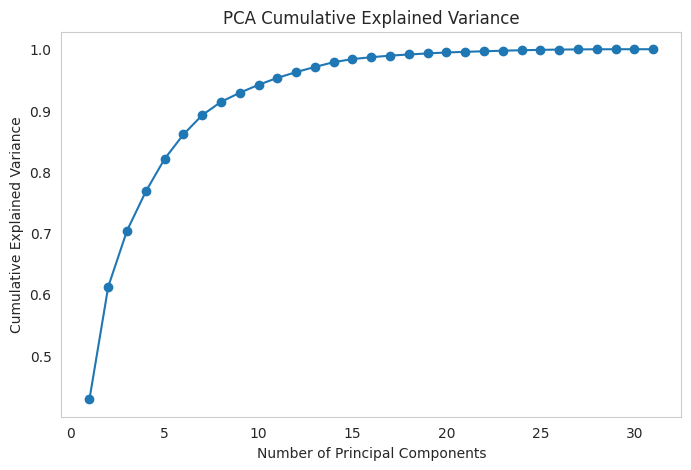

In [7]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.title("PCA Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")

plt.grid()
plt.show()

In [10]:
pca_2 = PCA(n_components=2)

X_pca_2 = pca_2.fit_transform(X_scaled)

print("Reduced Data Shape:", X_pca_2.shape)

Reduced Data Shape: (569, 2)


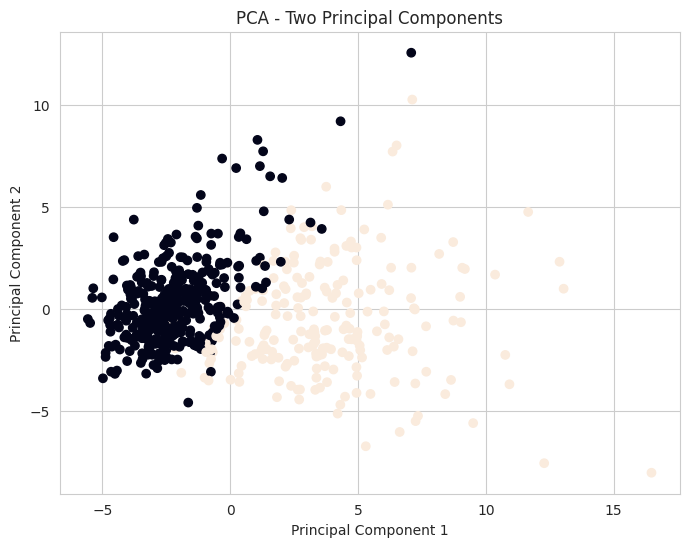

In [17]:
diagnosis_numeric = df["diagnosis"].map({
    "B": 0,
    "M": 1
})
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca_2[:, 0],
    X_pca_2[:, 1],
    c=diagnosis_numeric
)

plt.title("PCA - Two Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [18]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(
    n_components=2,
    random_state=23
)

X_svd = svd.fit_transform(X_scaled)

print("SVD Reduced Shape:", X_svd.shape)

SVD Reduced Shape: (569, 2)


In [19]:
print(
    "SVD Explained Variance:",
    svd.explained_variance_ratio_
)

SVD Explained Variance: [0.42864701 0.18376792]


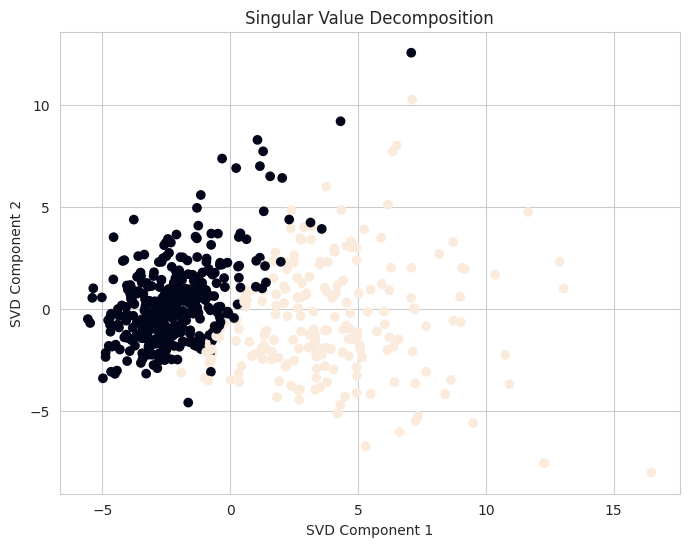

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_svd[:,0],
    X_svd[:,1],
    c=diagnosis_numeric
)

plt.title("Singular Value Decomposition")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")

plt.show()

In [22]:
from sklearn.decomposition import FactorAnalysis

factor = FactorAnalysis(
    n_components=2,
    random_state=23
)

X_factor = factor.fit_transform(X_scaled)

print("Factor Analysis Shape:", X_factor.shape)

Factor Analysis Shape: (569, 2)


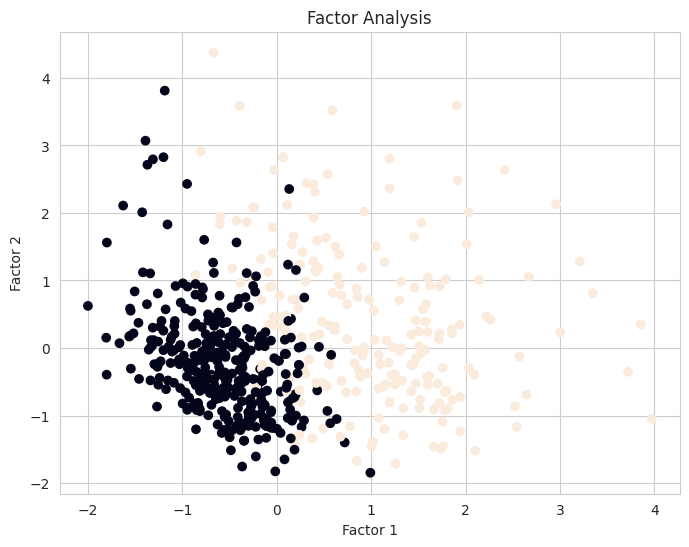

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_factor[:,0],
    X_factor[:,1],
    c=diagnosis_numeric
)

plt.title("Factor Analysis")
plt.xlabel("Factor 1")
plt.ylabel("Factor 2")

plt.show()

In [25]:
pca_full = PCA()

pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print(
    "Components required to explain 95% variance:",
    n_components_95
)

Components required to explain 95% variance: 11


In [26]:
from sklearn.manifold import MDS

mds = MDS(
    n_components=2,
    random_state=23,
    n_init=1,
    max_iter=300
)

X_mds = mds.fit_transform(
    X_scaled
)

print("MDS Shape:", X_mds.shape)

MDS Shape: (569, 2)


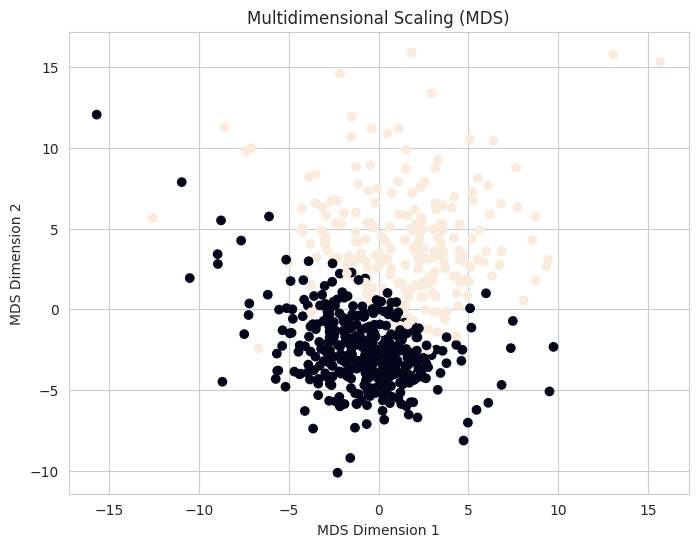

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_mds[:,0],
    X_mds[:,1],
    c=diagnosis_numeric
)

plt.title("Multidimensional Scaling (MDS)")
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")

plt.show()

In [29]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=23,
    perplexity=30
)

X_tsne = tsne.fit_transform(
    X_scaled
)

print("t-SNE Shape:", X_tsne.shape)

t-SNE Shape: (569, 2)


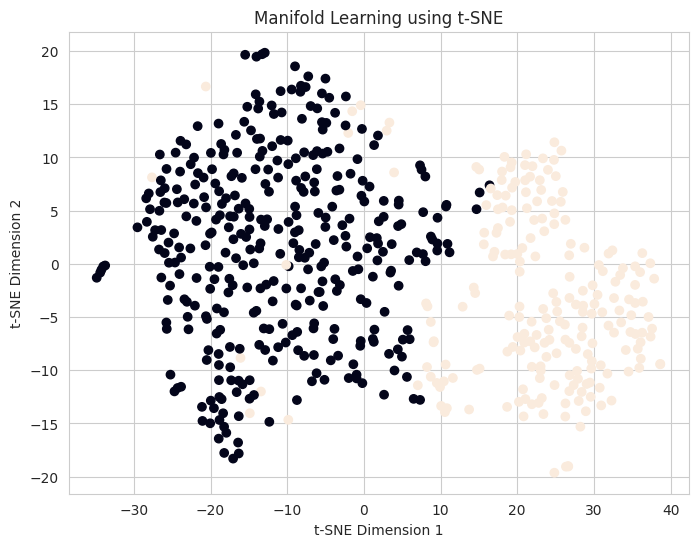

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=diagnosis_numeric
)

plt.title("Manifold Learning using t-SNE")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.show()

In [32]:
from minisom import MiniSom

som = MiniSom(
    10,
    10,
    X_scaled.shape[1],
    sigma=1.0,
    learning_rate=0.5,
    random_seed=23
)

som.random_weights_init(X_scaled)

som.train_random(
    X_scaled,
    100
)

print("SOM training completed.")

SOM training completed.


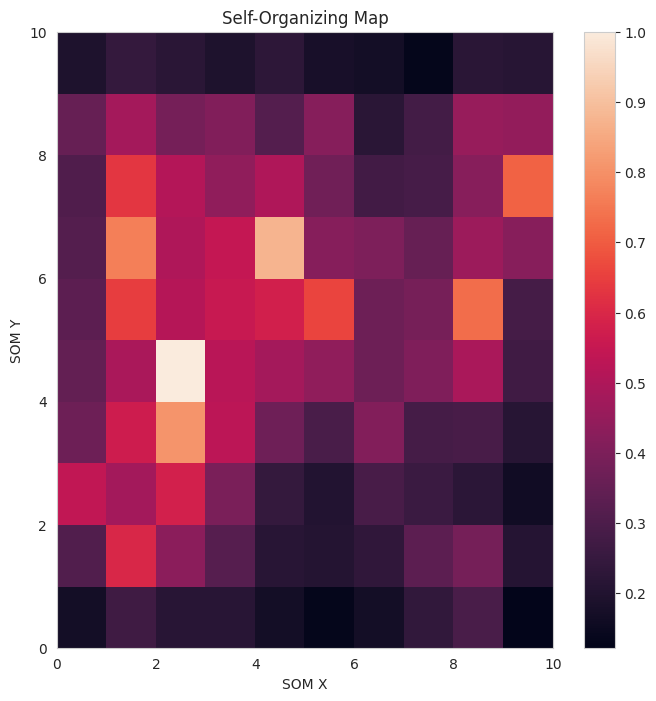

In [33]:
plt.figure(figsize=(8,8))

plt.pcolor(
    som.distance_map().T
)

plt.colorbar()

plt.title("Self-Organizing Map")
plt.xlabel("SOM X")
plt.ylabel("SOM Y")

plt.show()

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

regression_df = df.select_dtypes(include=np.number).copy()

regression_df = regression_df.dropna(axis=1, how="all")

regression_df = regression_df.fillna(regression_df.median())

y_reg = regression_df["area_mean"]

X_reg = regression_df.drop(columns=["area_mean"], errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=23
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 14.178300899601533
Mean Squared Error: 385.93145164870253
Root Mean Squared Error: 19.64513811732314
R2 Score: 0.9974408109315835


In [36]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

y_pred = linear_model.predict(
    X_test
)

print("Linear Regression Model Created")

Linear Regression Model Created


In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 14.178300899601533
MSE: 385.93145164870253
RMSE: 19.64513811732314
R² Score: 0.9974408109315835


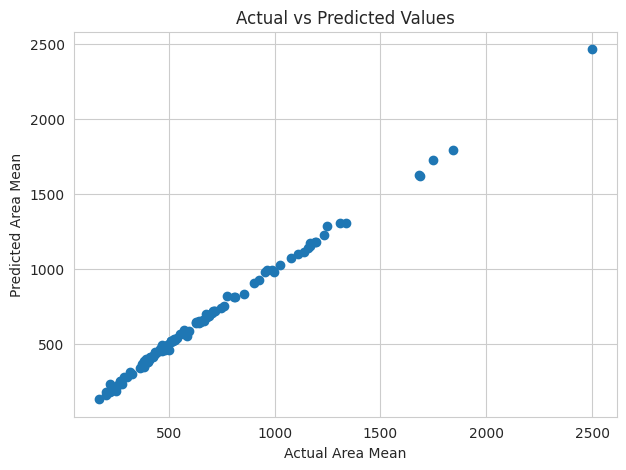

In [38]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    y_pred
)

plt.title("Actual vs Predicted Values")
plt.xlabel("Actual Area Mean")
plt.ylabel("Predicted Area Mean")

plt.show()

In [39]:
accuracy = 100 * (
    1 -
    np.mean(
        np.abs(
            (y_test - y_pred) / y_test
        )
    )
)

print("Approximate Prediction Accuracy:", accuracy, "%")

Approximate Prediction Accuracy: 96.93965725234958 %
